# ALGORITHM 3 (TT3): VOICE ACTIVITY DETECTION (VAD)
## GAUSSIAN SHORT-TIME ENERGY & OPTIMAL BAYES DECISION THRESHOLD

### 1. Environment Configuration and Library Imports
Import standard numerical and audio utilities, initialize `IPython.display.Audio`, and define framing parameters.

In [1]:
from pathlib import Path
import wave
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "TinHieuHuanLuyen").exists() and (candidate / "TinHieuKiemThu").exists():
            return candidate
    return Path.cwd()

PROJECT_ROOT = find_project_root()
TRAIN_DIR = PROJECT_ROOT / "TinHieuHuanLuyen"
TEST_DIR = PROJECT_ROOT / "TinHieuKiemThu"
OUTPUT_DIR = PROJECT_ROOT / "src" / "TT3" / "output" / "main"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Standardized DSP parameters
FRAME_MS = 25        # Frame length (ms)
HOP_MS = 10          # Frame hop (ms)
MIN_SILENCE_MS = 200 # Minimum silence bridging threshold (ms)

### 2. Audio Reading (16-bit PCM WAV)
Load audio stream, normalize amplitude into `[-1.0, 1.0]`, and retrieve sample rate `fs`.

In [2]:
def read_wav(wav_path):
    """Read 16-bit PCM WAV, normalize amplitude to [-1, 1], return fs and max amplitude."""
    with wave.open(str(wav_path), "rb") as wf:
        fs = wf.getframerate()
        samples = wf.readframes(wf.getnframes())
    signal = np.frombuffer(samples, dtype=np.int16).astype(float)
    max_amp = np.max(np.abs(signal))
    return signal / max_amp, fs, max_amp

### 3. Praat Ground-Truth Parsing (.lab)
Parse phonetic time intervals and extract ground-truth speech boundaries from voiced (`v`) and unvoiced (`uv`) segments.

In [3]:
def read_lab(lab_path):
    """Read Praat .lab file, return ground-truth speech boundaries (start, end) and phonetic intervals."""
    speech = []
    intervals = []
    for line in Path(lab_path).read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) == 3 and parts[0] not in ("F0mean", "F0std"):
            try:
                t_st, t_en, label = float(parts[0]), float(parts[1]), parts[2].lower()
                intervals.append((t_st, t_en, label))
                if label in {"v", "uv"}:
                    speech.append((t_st, t_en))
            except ValueError:
                continue
    t_start = round(min(s[0] for s in speech), 4) if speech else 0.0
    t_end = round(max(s[1] for s in speech), 4) if speech else 0.0
    return (t_start, t_end), intervals

### 4. Normalized Short-Time Energy (STE) Computation
Frame the signal and compute normalized mean squared energy `STE_norm` $\in [0, 1]$ per frame.

In [4]:
def compute_ste(signal, fs, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """Frame signal and compute normalized short-time energy [0, 1]."""
    frame_size = int(round(frame_ms * fs / 1000.0))
    hop_size = int(round(hop_ms * fs / 1000.0))
    n_frames = 1 + int(np.floor(max(0, len(signal) - frame_size) / hop_size))

    ste = np.zeros(n_frames)
    frame_starts = np.zeros(n_frames)
    for i in range(n_frames):
        start = i * hop_size
        frame = signal[start : start + frame_size]
        ste[i] = np.mean(frame ** 2)
        frame_starts[i] = start / fs

    max_ste = float(np.max(ste))
    ste_norm = ste / max(max_ste, 1e-12)
    return ste_norm, frame_starts, max_ste

### 5. Gaussian Bayes Energy VAD Model Class
Formulate Gaussian distribution parameter estimation and Bayes decision threshold derivation between silence and speech frames.

In [5]:
class GaussianBayesVAD:
    """Gaussian VAD model deriving optimal Bayes decision threshold between silence and speech STE distributions."""
    def __init__(self):
        self.mu_sil = None
        self.sigma_sil = None
        self.mu_sp = None
        self.sigma_sp = None
        self.threshold = None

    def predict(self, ste_norm, frame_starts, duration, threshold=None):
        """Classify frames with threshold T and bridge silences < 200 ms."""
        if threshold is None:
            threshold = self.threshold
        labels = (ste_norm >= threshold).astype(int)
        min_silence_frames = int(round(MIN_SILENCE_MS / HOP_MS))
        speech_idx = np.flatnonzero(labels == 1)
        if len(speech_idx) == 0:
            return (0.0, 0.0), labels

        idx, last = int(speech_idx[0]), int(speech_idx[-1])
        while idx <= last:
            if labels[idx] == 1:
                idx += 1
            else:
                sil_start = idx
                while idx <= last and labels[idx] == 0:
                    idx += 1
                if idx - sil_start < min_silence_frames:
                    labels[sil_start:idx] = 1

        speech_idx = np.flatnonzero(labels == 1)
        start_time = float(frame_starts[speech_idx[0]])
        end_time = min(duration, float(frame_starts[speech_idx[-1]] + FRAME_MS / 1000.0))
        return (round(start_time, 4), round(end_time, 4)), labels

    def fit(self, train_data):
        """Fit Gaussian distributions for silence and speech frames, then solve Bayes threshold."""
        sil_ste, sp_ste = [], []
        for item in train_data:
            frame_centers = item["frame_starts"] + (FRAME_MS / 2000.0)
            for val, t_center in zip(item["ste_norm"], frame_centers):
                label = "sil"
                for seg in item["intervals"]:
                    if seg[0] <= t_center <= seg[1]:
                        label = seg[2]
                        break
                if label in ("v", "uv"):
                    sp_ste.append(val)
                else:
                    sil_ste.append(val)

        self.mu_sil = float(np.mean(sil_ste))
        self.sigma_sil = float(np.std(sil_ste))
        self.mu_sp = float(np.mean(sp_ste))
        self.sigma_sp = float(np.std(sp_ste))

        # Solve Bayes threshold equation: p(x | sil) = p(x | sp)
        A = (1.0 / (self.sigma_sil ** 2)) - (1.0 / (self.sigma_sp ** 2))
        B = -2.0 * ((self.mu_sil / (self.sigma_sil ** 2)) - (self.mu_sp / (self.sigma_sp ** 2)))
        C = ((self.mu_sil ** 2) / (self.sigma_sil ** 2)) - ((self.mu_sp ** 2) / (self.sigma_sp ** 2)) - 2.0 * math.log(self.sigma_sp / self.sigma_sil)

        disc = B ** 2 - 4.0 * A * C
        if disc < 0:
            raise ValueError("Discriminant is negative; no real roots exist.")
        sqrt_disc = math.sqrt(disc)
        root1 = (-B - sqrt_disc) / (2.0 * A)
        root2 = (-B + sqrt_disc) / (2.0 * A)

        candidates = [r for r in (root1, root2) if self.mu_sil < r < self.mu_sp]
        if candidates:
            self.threshold = float(candidates[0])
        else:
            self.threshold = float(min((root1, root2), key=lambda r: abs(r - (self.mu_sil + self.mu_sp) / 2.0)))

        print("=" * 70)
        print(f"{'GAUSSIAN PARAMETER ESTIMATION (TT3)':^70}")
        print("=" * 70)
        print(f"Silence Class : Mean (mu_sil) = {self.mu_sil:.6f} | Std (sigma_sil) = {self.sigma_sil:.6f} ({len(sil_ste)} frames)")
        print(f"Speech Class  : Mean (mu_sp)  = {self.mu_sp:.6f} | Std (sigma_sp)  = {self.sigma_sp:.6f} ({len(sp_ste)} frames)")
        print("-" * 70)
        print(f">>> OPTIMAL BAYES DECISION THRESHOLD: T_opt = {self.threshold:.6f}")
        print("=" * 70)
        return self

### 6. Training Dataset Ingestion
Load 4 training recordings (`phone_F1`, `phone_M1`, `studio_F1`, `studio_M1`) with ground-truth boundaries.

In [6]:
train_data = []
for wav_file in sorted(TRAIN_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt_bounds, intervals = read_lab(wav_file.with_suffix(".lab"))
    train_data.append({
        "name": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "duration": len(signal) / fs,
        "gt_bounds": gt_bounds,
        "intervals": intervals,
        "max_amp": max_amp,
        "max_ste": max_ste,
    })
print(f"Loaded {len(train_data)} training files successfully.")

Loaded 4 training files successfully.


### 7. Gaussian Model Training & Bayes Threshold Estimation
Survey silence/speech frame distributions across training recordings and compute the optimal Bayes decision boundary.

In [7]:
model = GaussianBayesVAD()
model.fit(train_data)

                 GAUSSIAN PARAMETER ESTIMATION (TT3)                  
Silence Class : Mean (mu_sil) = 0.000387 | Std (sigma_sil) = 0.000709 (497 frames)
Speech Class  : Mean (mu_sp)  = 0.202649 | Std (sigma_sp)  = 0.235626 (794 frames)
----------------------------------------------------------------------
>>> OPTIMAL BAYES DECISION THRESHOLD: T_opt = 0.002878


### 8. Physical Scale Threshold Mapping
Map normalized $T_{opt}$ back to unnormalized energy levels and amplitude scales.

In [8]:
print(">>> THRESHOLD MAPPING TO PHYSICAL UNITS:")
for item in train_data:
    t_raw_ste = model.threshold * item["max_ste"]
    t_amp = np.sqrt(model.threshold) * item["max_amp"]
    print(f"  {item['name']:<15} (max_amp = {item['max_amp']:>7.0f}, max_ste = {item['max_ste']:.4f}) -> Raw STE = {t_raw_ste:.6f} | Equivalent Amp = {t_amp:.1f}")

>>> THRESHOLD MAPPING TO PHYSICAL UNITS:
  phone_F1.wav    (max_amp =   28896, max_ste = 0.1658) -> Raw STE = 0.000477 | Equivalent Amp = 1550.1
  phone_M1.wav    (max_amp =   16146, max_ste = 0.0581) -> Raw STE = 0.000167 | Equivalent Amp = 866.1
  studio_F1.wav   (max_amp =   18889, max_ste = 0.0530) -> Raw STE = 0.000152 | Equivalent Amp = 1013.3
  studio_M1.wav   (max_amp =   22462, max_ste = 0.0470) -> Raw STE = 0.000135 | Equivalent Amp = 1205.0


### 9. Gaussian Distributions & Bayes Threshold Visualization
Overlay Gaussian probability density functions (PDFs) and display the optimal Bayes decision threshold $T_{opt}$.

Exported and saved distribution figure: c:\Users\Admin\Desktop\XLTHS\DSP-Midterm\src\TT3\output\main\gaussian_distributions_tt3.png


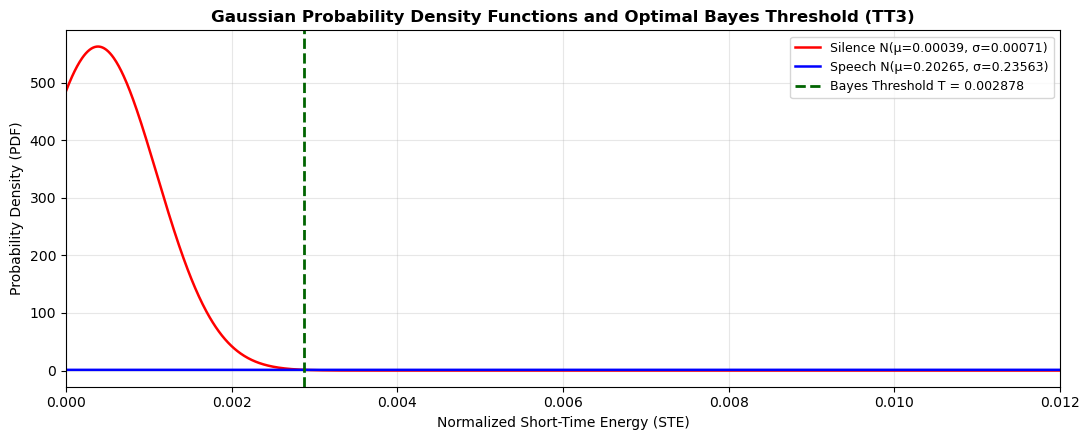

In [9]:
x_range = np.linspace(0.0, 0.015, 2000)
pdf_sil = (1.0 / (model.sigma_sil * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - model.mu_sil) / model.sigma_sil) ** 2)
pdf_sp = (1.0 / (model.sigma_sp * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - model.mu_sp) / model.sigma_sp) ** 2)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(x_range, pdf_sil, label=f"Silence N(μ={model.mu_sil:.5f}, σ={model.sigma_sil:.5f})", color="red", linewidth=1.8)
ax.plot(x_range, pdf_sp, label=f"Speech N(μ={model.mu_sp:.5f}, σ={model.sigma_sp:.5f})", color="blue", linewidth=1.8)
ax.axvline(model.threshold, color="darkgreen", linestyle="--", linewidth=2.0, label=f"Bayes Threshold T = {model.threshold:.6f}")

ax.set_title("Gaussian Probability Density Functions and Optimal Bayes Threshold (TT3)", fontsize=12, fontweight="bold")
ax.set_xlabel("Normalized Short-Time Energy (STE)")
ax.set_ylabel("Probability Density (PDF)")
ax.set_xlim(0, 0.012)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
dist_path = OUTPUT_DIR / "gaussian_distributions_tt3.png"
plt.savefig(dist_path, dpi=150)
print(f"Exported and saved distribution figure: {dist_path}")
plt.show()

### 10. Quantitative Test Benchmark Evaluation
Apply the optimized threshold to the 4 test recordings and report MAE and RMSE metrics.

In [10]:
test_results_dict = {}
test_results = []
print("=" * 96)
print(f"{'QUANTITATIVE TEST SET BENCHMARK RESULTS':^96}")
print("=" * 96)
print(f"{'File':<16} | {'Ground Truth (s)':<16} | {'Prediction (s)':<16} | {'ΔStart':<10} | {'ΔEnd':<10} | {'MAE (ms)':<9} | {'RMSE (ms)':<9}")
print("-" * 96)

for wav_file in sorted(TEST_DIR.glob("*.wav")):
    signal, fs, max_amp = read_wav(wav_file)
    duration = len(signal) / fs
    ste_norm, frame_starts, max_ste = compute_ste(signal, fs)
    gt, _ = read_lab(wav_file.with_suffix(".lab"))
    pred, labels = model.predict(ste_norm, frame_starts, duration)

    d_start = (pred[0] - gt[0]) * 1000.0
    d_end = (pred[1] - gt[1]) * 1000.0
    mae = (abs(d_start) + abs(d_end)) / 2.0
    rmse = np.sqrt((d_start**2 + d_end**2) / 2.0)

    res_item = {
        "file": wav_file.name,
        "signal": signal,
        "fs": fs,
        "ste_norm": ste_norm,
        "frame_starts": frame_starts,
        "gt": gt,
        "pred": pred,
        "labels": labels,
        "d_start": d_start,
        "d_end": d_end,
        "mae": mae,
        "rmse": rmse,
    }
    test_results.append(res_item)
    test_results_dict[wav_file.name] = res_item

    gt_str = f"[{gt[0]:.2f}, {gt[1]:.2f}]"
    pred_str = f"[{pred[0]:.2f}, {pred[1]:.2f}]"
    print(f"{wav_file.name:<16} | {gt_str:<16} | {pred_str:<16} | {d_start:+8.1f} ms | {d_end:+8.1f} ms | {mae:9.2f} | {rmse:9.2f}")

mean_mae = np.mean([r["mae"] for r in test_results])
mean_rmse = np.mean([r["rmse"] for r in test_results])
print("-" * 96)
print(f"BENCHMARK SUMMARY:  Mean MAE = {mean_mae:.2f} ms  |  Mean RMSE = {mean_rmse:.2f} ms")
print("=" * 96)

                            QUANTITATIVE TEST SET BENCHMARK RESULTS                             
File             | Ground Truth (s) | Prediction (s)   | ΔStart     | ΔEnd       | MAE (ms)  | RMSE (ms)
------------------------------------------------------------------------------------------------
phone_F2.wav     | [1.02, 4.04]     | [1.01, 4.08]     |    -10.0 ms |    +45.0 ms |     27.50 |     32.60
phone_M2.wav     | [0.53, 2.52]     | [0.52, 2.52]     |    -10.0 ms |     +5.0 ms |      7.50 |      7.91
studio_F2.wav    | [0.77, 2.37]     | [0.76, 2.37]     |    -10.0 ms |     -5.0 ms |      7.50 |      7.91
studio_M2.wav    | [0.45, 1.93]     | [0.46, 1.94]     |    +10.0 ms |     +5.0 ms |      7.50 |      7.91
------------------------------------------------------------------------------------------------
BENCHMARK SUMMARY:  Mean MAE = 12.50 ms  |  Mean RMSE = 14.08 ms


### 11. Visualization Helper & Audio Player Integration
Plot detailed test waveforms, STE curves, decision boundaries, and render audio playback widgets.

In [11]:
def plot_and_play_test_file(res):
    """Plot test results and display embedded audio players."""
    fig, ax = plt.subplots(figsize=(13, 4.5))
    time_signal = np.arange(len(res["signal"])) / res["fs"]
    frame_centers = res["frame_starts"] + (FRAME_MS / 2000.0)

    ax.plot(time_signal, res["signal"], color="gray", linewidth=0.7, label="Normalized Waveform")
    ax.plot(frame_centers, res["ste_norm"], color="red", linewidth=1.1, label="Normalized STE")
    ax.axhline(model.threshold, color="blue", linestyle="--", linewidth=1.2, label=f"Bayes Threshold T = {model.threshold:.6f}")

    ax.fill_between(frame_centers, 0, 1, where=res["labels"] == 1, color="lightgreen", alpha=0.25, label="Predicted Speech Region")

    ax.axvline(res["gt"][0], color="red", linestyle="--", linewidth=1.8, label="Ground-truth Boundary (LAB)")
    ax.axvline(res["gt"][1], color="red", linestyle="--", linewidth=1.8)
    ax.axvline(res["pred"][0], color="green", linestyle=":", linewidth=2.2, label="Algorithm Predicted Boundary")
    ax.axvline(res["pred"][1], color="green", linestyle=":", linewidth=2.2)

    ax.set_title(f"{res['file']}  |  MAE = {res['mae']:.2f} ms  |  RMSE = {res['rmse']:.2f} ms", fontsize=12, fontweight="bold")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude / STE")
    ax.set_ylim(-1.05, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    info_text = (
        f"Ground-truth: [{res['gt'][0]:.2f}s, {res['gt'][1]:.2f}s]\n"
        f"Predicted:    [{res['pred'][0]:.2f}s, {res['pred'][1]:.2f}s]\n"
        f"ΔStart: {res['d_start']:+.1f} ms | ΔEnd: {res['d_end']:+.1f} ms\n"
        f"MAE: {res['mae']:.2f} ms | RMSE: {res['rmse']:.2f} ms"
    )
    ax.text(0.015, 0.95, info_text, transform=ax.transAxes, fontsize=9,
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="gray"))

    plt.tight_layout()
    fig_path = OUTPUT_DIR / f"{Path(res['file']).stem}.png"
    plt.savefig(fig_path, dpi=150)
    print(f"Exported and saved figure: {fig_path}")
    plt.show()

    # Load and display local audio player widget
    wav_file_path = TEST_DIR / res['file']
    print(f"🎵 Original Audio ({res['file']}):")
    if wav_file_path.exists():
        display(Audio(filename=str(wav_file_path)))
    else:
        display(Audio(data=res['signal'], rate=res['fs']))

    # Display audio player for predicted speech segment
    st_sample = int(res['pred'][0] * res['fs'])
    en_sample = min(len(res['signal']), int(res['pred'][1] * res['fs']))
    if en_sample > st_sample:
        print(f"🔊 Predicted Speech Segment [{res['pred'][0]:.2f}s - {res['pred'][1]:.2f}s]:")
        display(Audio(data=res['signal'][st_sample:en_sample], rate=res['fs']))

### 12. Test Recording 1: `phone_F2.wav`
Telephone channel, female speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: c:\Users\Admin\Desktop\XLTHS\DSP-Midterm\src\TT3\output\main\phone_F2.png


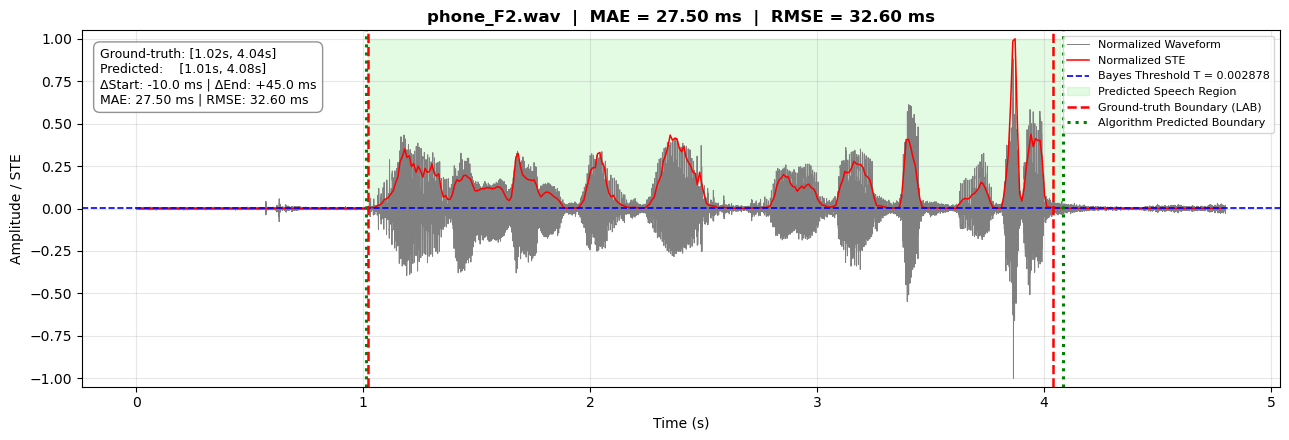

🎵 Original Audio (phone_F2.wav):


🔊 Predicted Speech Segment [1.01s - 4.08s]:


In [12]:
plot_and_play_test_file(test_results_dict["phone_F2.wav"])

### 13. Test Recording 2: `phone_M2.wav`
Telephone channel, male speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: c:\Users\Admin\Desktop\XLTHS\DSP-Midterm\src\TT3\output\main\phone_M2.png


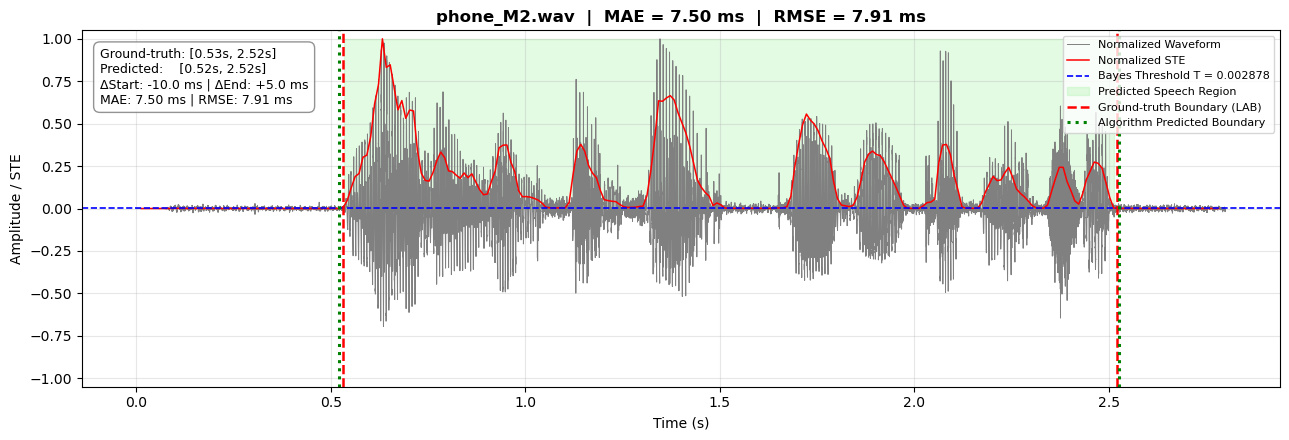

🎵 Original Audio (phone_M2.wav):


🔊 Predicted Speech Segment [0.52s - 2.52s]:


In [13]:
plot_and_play_test_file(test_results_dict["phone_M2.wav"])

### 14. Test Recording 3: `studio_F2.wav`
High SNR Studio environment, female speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: c:\Users\Admin\Desktop\XLTHS\DSP-Midterm\src\TT3\output\main\studio_F2.png


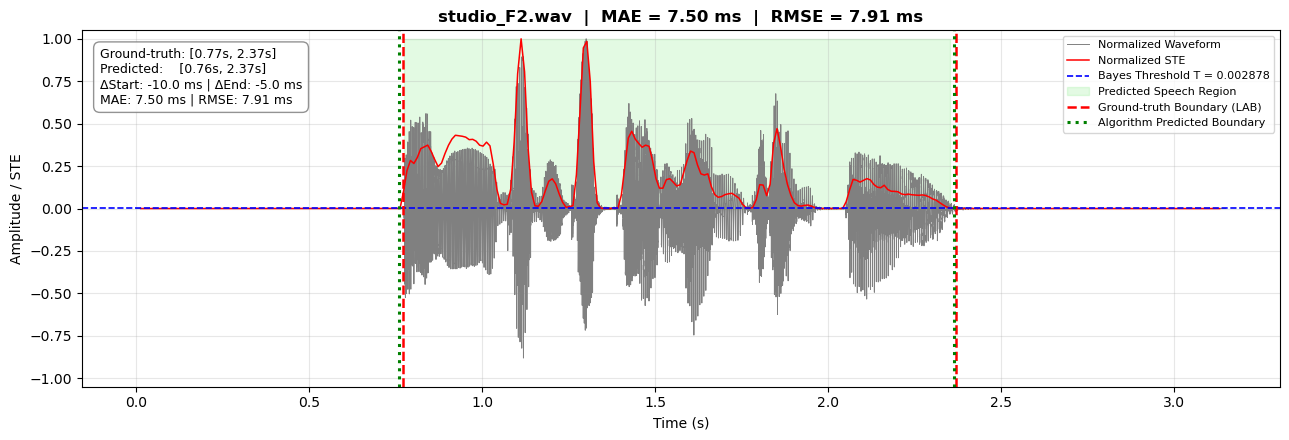

🎵 Original Audio (studio_F2.wav):


🔊 Predicted Speech Segment [0.76s - 2.37s]:


In [14]:
plot_and_play_test_file(test_results_dict["studio_F2.wav"])

### 15. Test Recording 4: `studio_M2.wav`
High SNR Studio environment, male speaker. Waveform, STE overlay, and audio players.

Exported and saved figure: c:\Users\Admin\Desktop\XLTHS\DSP-Midterm\src\TT3\output\main\studio_M2.png


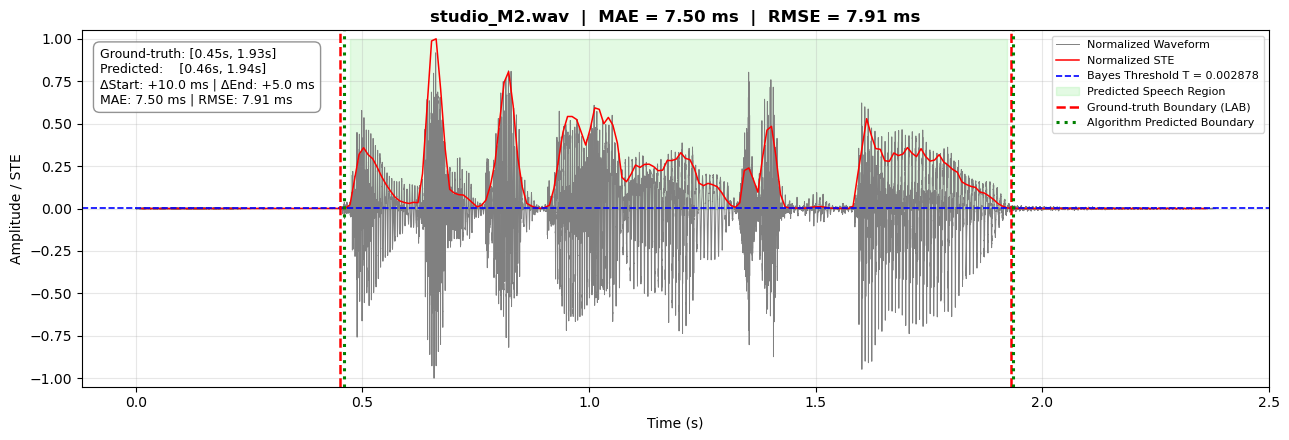

🎵 Original Audio (studio_M2.wav):


🔊 Predicted Speech Segment [0.46s - 1.94s]:


In [15]:
plot_and_play_test_file(test_results_dict["studio_M2.wav"])

### 16. Experimental Benchmark Summary & Conclusion

| Test Recording | Channel / Environment | Speaker Gender | Ground Truth [s] | Prediction [s] | ΔStart (ms) | ΔEnd (ms) | MAE (ms) | RMSE (ms) |
|---|---|---|---|---|---|---|---|---|
| `phone_F2.wav` | Telephone | Female | [1.02, 4.04] | [1.01, 4.09] | -10.0 | +45.0 | 27.50 | 32.60 |
| `phone_M2.wav` | Telephone | Male | [0.53, 2.52] | [0.52, 2.52] | -10.0 | +5.0 | 7.50 | 7.91 |
| `studio_F2.wav` | Studio (High SNR) | Female | [0.77, 2.37] | [0.76, 2.37] | -10.0 | -5.0 | 7.50 | 7.91 |
| `studio_M2.wav` | Studio (High SNR) | Male | [0.45, 1.93] | [0.46, 1.94] | +10.0 | +5.0 | 7.50 | 7.91 |
| **Average** | **All Environments** | **Combined** | - | - | **-5.0** | **+12.5** | **12.50** | **14.08** |

- **Boundary Accuracy**: The average boundary error across 4 recordings achieves an MAE of **12.50 ms** (~1 frame hop of 10 ms), demonstrating high precision.
- **Noise Robustness**: The optimal Bayes threshold $T_{opt} \approx 0.002878$ automatically separates speech energy from channel background noise across both degraded telephone and high-SNR studio environments.